In [1]:
import numpy as np
import feos
import si_units as si
import matplotlib.pyplot as plt
import thermoift.FeosPlugin as TC
import thermoift.PLOT_SETTINGS as ps
import thermoift.semi_emperical_correlations as SEC

In [2]:
COMPONENT_NAMES = ["carbon dioxide", "hydrogen", "argon"]
FEED_Z          = np.array([0.95, 0.02, 0.03], dtype=float)
FEED_Z          = FEED_Z / FEED_Z.sum()

In [3]:
params          = TC.PARAMETERS(COMPONENT_NAMES)
eos             = feos.HelmholtzEnergyFunctional.pcsaft(params)
feed_si         = FEED_Z * si.MOL
Tc_si, Pc_si    = TC.VLECalculator.compute_critical_point(eos, FEED_Z, T_guess=300.0)
Tc_K            = Tc_si / si.KELVIN
Pc_bar          = Pc_si / si.BAR
T_vals          = np.linspace(200.0, Tc_K , 500)
T_bub, P_bub    = TC.VLECalculator.compute_bubble_curve(eos, T_vals, feed_si, verbose=False)
T_dew, P_dew    = TC.VLECalculator.compute_dew_curve(eos, T_vals, feed_si, verbose=False)

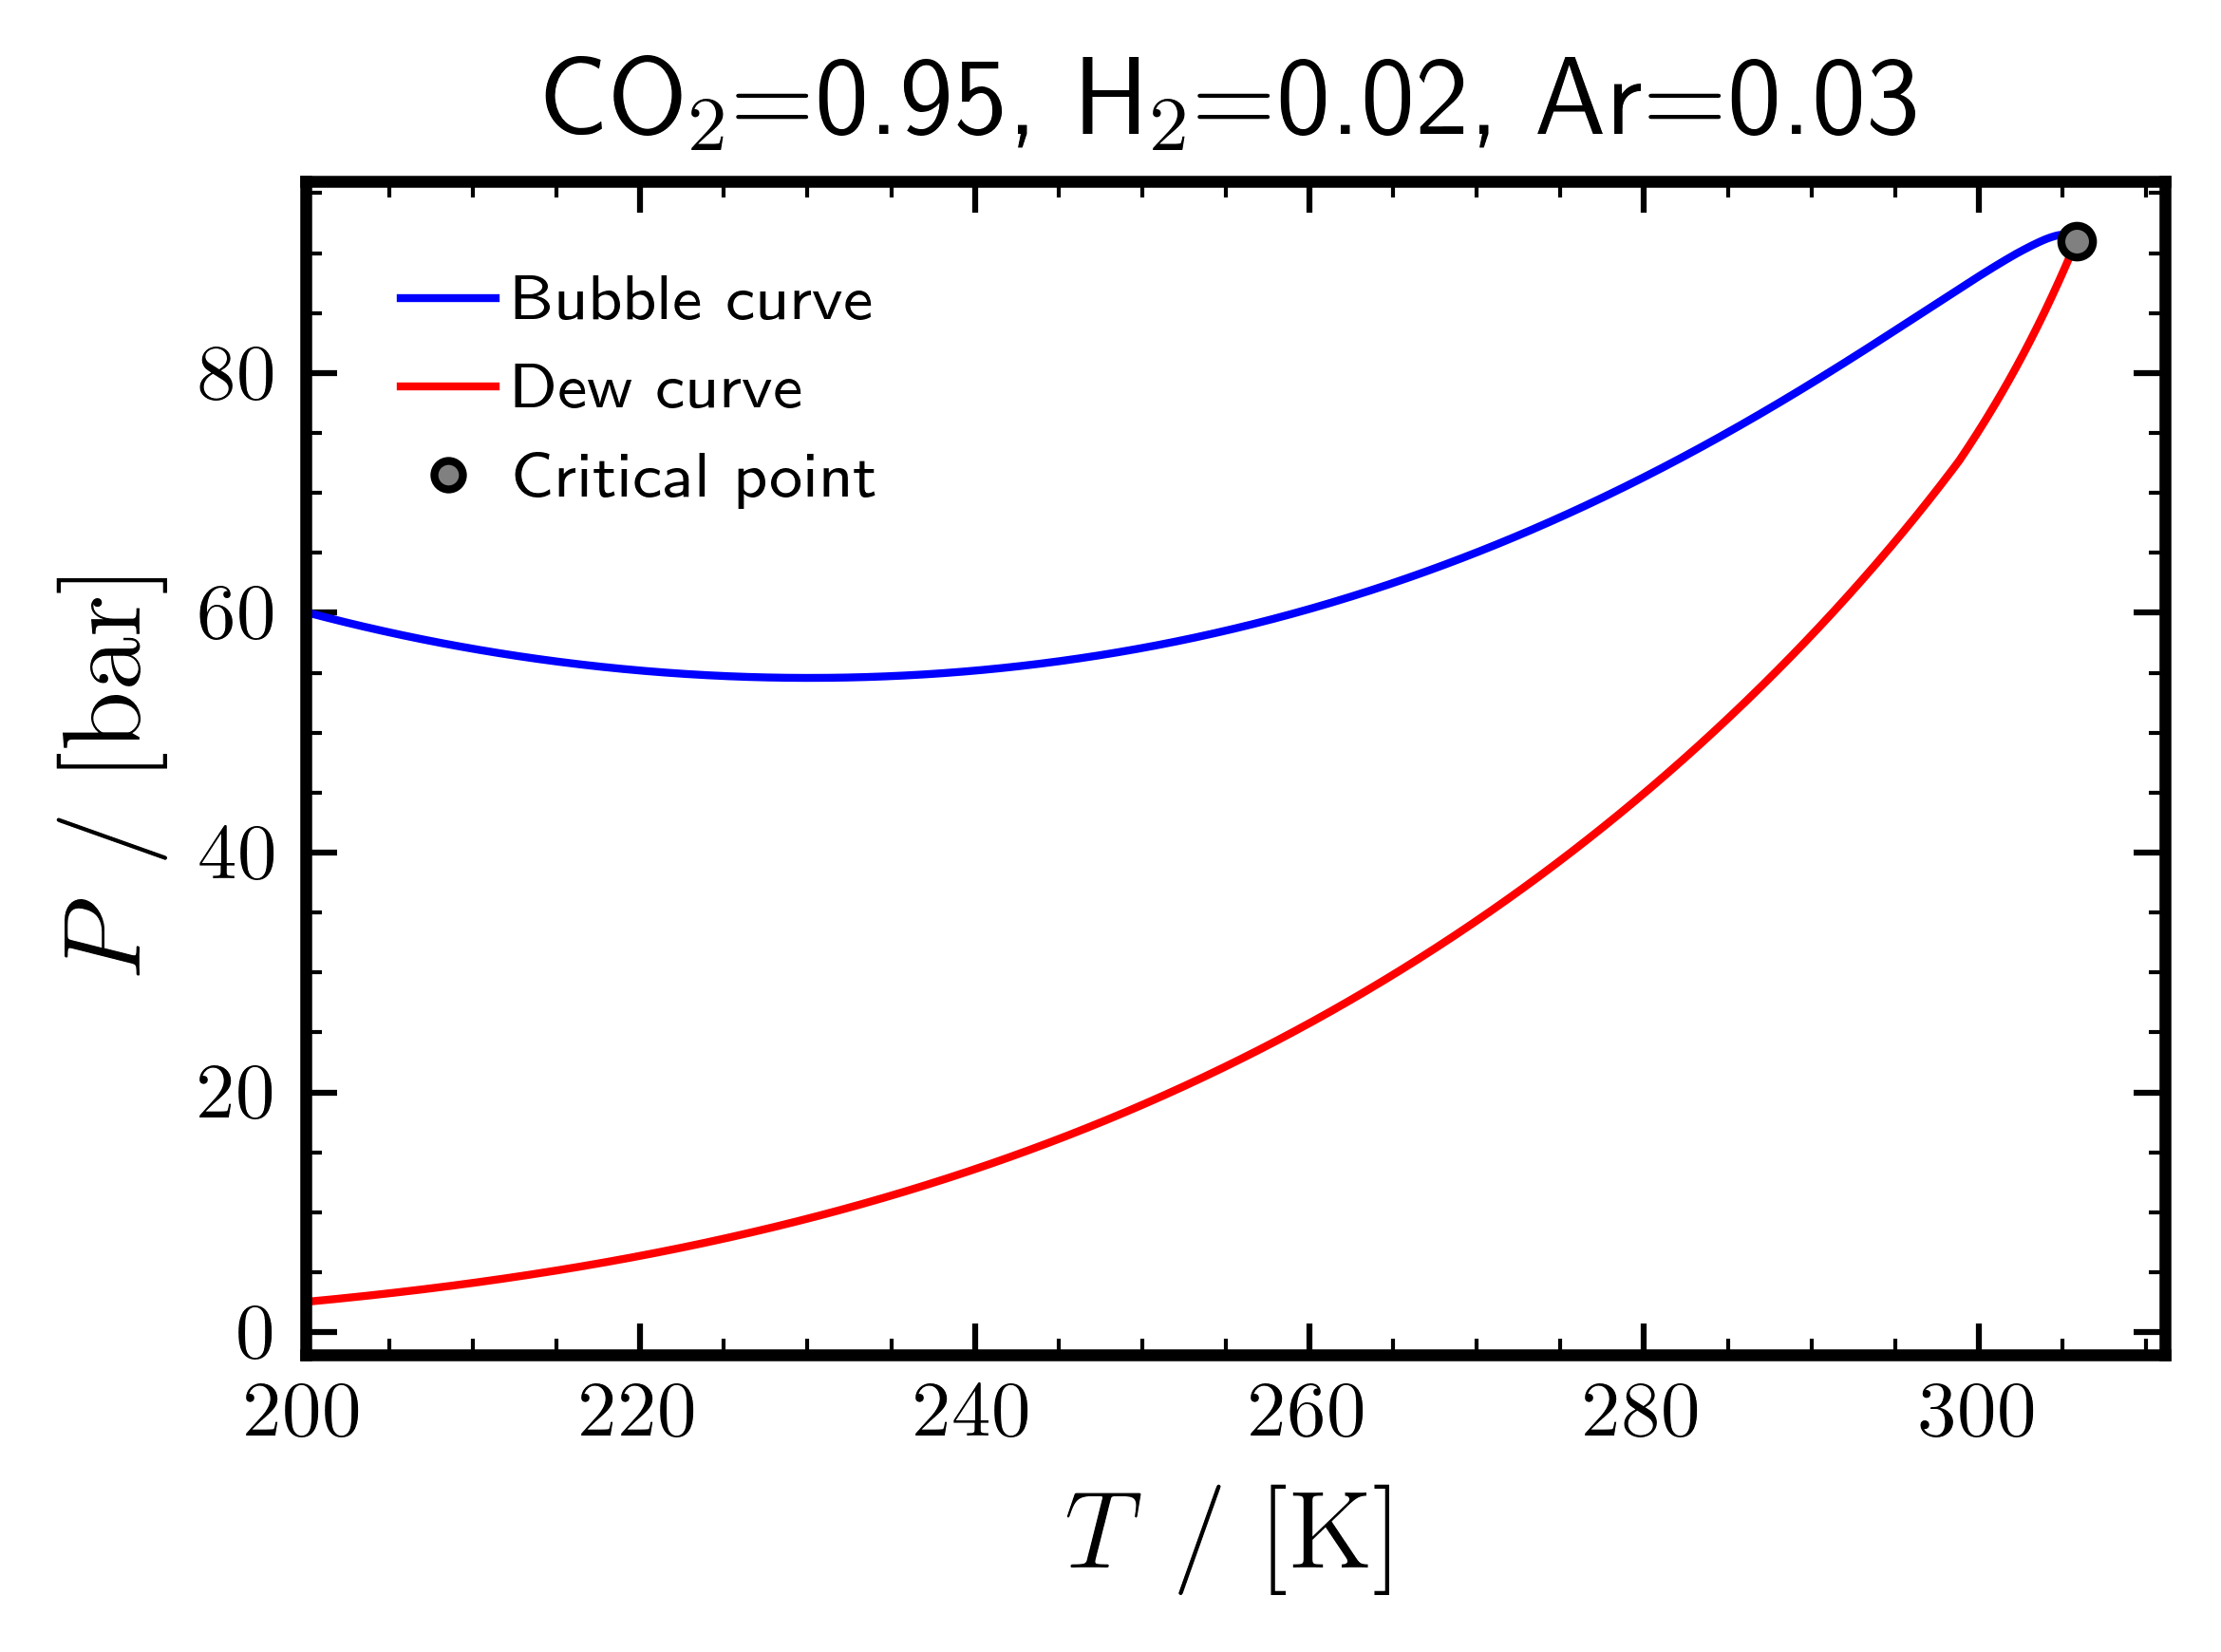

In [4]:
# Build PT_results dict in the format expected by PlottingEngine
feed_key = "feed_0"
PT_results = {
    feed_key: {
        "bubble": [{"T_K": T, "P_bar": P} for T, P in zip(T_bub, P_bub)],
        "dew": [{"T_K": T, "P_bar": P} for T, P in zip(T_dew, P_dew)],
        "TC_K": Tc_K,
        "PC_bar": Pc_bar,
        "z": FEED_Z,
    }
}

# Plot using PlottingEngine
fig, ax = TC.PlottingEngine.plot_phase_diagram(PT_results, feed_key, params)
plt.show()

In [5]:
T_K             = 250.0                        # Input temperature (K)
P_bub_T         = np.interp(T_K, T_bub, P_bub)
P_dew_T         = np.interp(T_K, T_dew, P_dew)
P_bar           = 0.5 * (P_dew_T + P_bub_T)    # Input pressure (bar)

eq, x, y, _, _  = TC.tp_flash(feos,eos, T_K*si.KELVIN, P_bar*si.BAR, feed_si, TC.molar_masses(params))

rho_l           = TC.molar_density_mol_m3(eq.liquid.density) * 1e-6
rho_v           = TC.molar_density_mol_m3(eq.vapor.density) * 1e-6

model                                   = SEC.semi_emperical_correlations()
gamma0, rhoL0, rhoV0, Tc0, Pc0, Psat0   = model.batch_pure_component_cDFT(COMPONENT_NAMES, T_K)
PARACHOR_NUMBERS                        = model.batch_parachor_numbers(COMPONENT_NAMES, T_K, n_exp=3.87, verbose=True)
kij_parachor                            = np.zeros((3, 3), dtype=float)

carbon dioxide: Parachor = 77.5437
hydrogen: T_K=250.00 > Tc=65.50, using T_ref=58.95 K -> Parachor = 34.0524
argon: T_K=250.00 > Tc=150.29, using T_ref=135.27 K -> Parachor = 56.5531


In [6]:
# ------------------------------------------------------------------------------
# Compute mixture IFT using parachor method at a single state point for testing
# -------------------------------------------------------------------------------
gamma_parachor = model.parachor_mixture_IFT(
    x=x,
    y=y,
    rho_l=rho_l,
    rho_v=rho_v,
    parachor_numbers=PARACHOR_NUMBERS,
    kij=kij_parachor,
    n_exp=3.87,
)

print("\n--- Results ---")
print("x =", x)
print("y =", y)
print(f"Parachor numbers = {PARACHOR_NUMBERS}")
print(f"Parachor gamma = {gamma_parachor:.6f} mN/m")


--- Results ---
x = [0.96851517 0.008535   0.02294983]
y = [0.54803505 0.26890548 0.18305947]
Parachor numbers = [77.54368101 34.05243163 56.5531433 ]
Parachor gamma = 7.471666 mN/m


In [7]:
# ------------------------------------------------------------------------------
# Compute mixture IFT using WSD method at a single state point for testing
# ------------------------------------------------------------------------------
gamma_wsd, mixcorr = model.wsd_mixture_IFT(
    T_K=T_K,
    x=x,
    y=y,
    rho_l=rho_l,
    rho_v=rho_v,
    phi=1.0,          # scalar or NxN matrix
    correction=True,
)

print("x =", x)
print("y =", y)
print(f"rho_l = {rho_l:.8e} mol/cm3")
print(f"rho_v = {rho_v:.8e} mol/cm3")
print("pure gamma0 =", gamma0)
print("pure Tc     =", Tc0)
print(f"WSD gamma   = {gamma_wsd:.6f} mN/m")
print(f"mixcorr     = {mixcorr:.6f}")

x = [0.96851517 0.008535   0.02294983]
y = [0.54803505 0.26890548 0.18305947]
rho_l = 2.36611098e-02 mol/cm3
rho_v = 2.14684936e-03 mol/cm3
pure gamma0 = [8.86799729        nan        nan]
pure Tc     = [309.14737606  65.50076682 150.29471988]
WSD gamma   = 7.901242 mN/m
mixcorr     = 0.968515
